In [1]:
from surprise import Dataset, Reader, SVDpp, accuracy
from surprise.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from surprise.model_selection import train_test_split
from collections import defaultdict
import pandas as pd
import numpy as np
import joblib, time
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

In [2]:
ratings = pd.read_csv(r"C:\Users\ACER\AppData\Roaming\Microsoft\Windows\Start Menu\Programs\Python 3.12\ratings_cleaned.csv")

In [3]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

In [4]:
param_grid = {
    'n_factors': [20, 50, 100],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.01, 0.02, 0.05]
}


In [5]:
print("Bắt đầu")
start = time.time()

gs = GridSearchCV(
    algo_class=SVDpp,
    param_grid=param_grid,
    measures=['rmse', 'mae'],
    cv=5,
    joblib_verbose=1,
    n_jobs=-1
)
gs.fit(data)

end = time.time()
duration = end - start

print("\nGridSearchCV hoàn tất!")
print(" Best RMSE:", gs.best_score['rmse'])
print(" Best Params:", gs.best_params['rmse'])
print(f"Thời gian chạy: {duration:.2f} giây ({duration/60:.2f} phút)")
# Lưu mô hình tốt nhất

Bắt đầu


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  5.6min



GridSearchCV hoàn tất!
 Best RMSE: 0.854421789388858
 Best Params: {'n_factors': 50, 'lr_all': 0.01, 'reg_all': 0.05}
Thời gian chạy: 4712.95 giây (78.55 phút)


[Parallel(n_jobs=-1)]: Done 135 out of 135 | elapsed: 78.5min finished


In [6]:
def precision_at_k(predictions, k=5, threshold=4.0):
    user_est_true = defaultdict(list)
    for pred in predictions:
        user_est_true[pred.uid].append((pred.est, pred.r_ui))
    precisions = []
    for user_ratings in user_est_true.values():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]
        hits = sum((true_r >= threshold) for (_, true_r) in top_k)
        precisions.append(hits / k)
    return np.mean(precisions)

In [7]:
print("\n Đánh giá chi tiết mô hình tốt nhất với KFold:")
kf = KFold(n_splits=5, random_state=42, shuffle=True)
results = []

best_model = gs.best_estimator['rmse']

for fold, (trainset, testset) in enumerate(kf.split(data), 1):
    print(f" Fold {fold} đang chạy...")
    best_model.fit(trainset)
    predictions = best_model.test(testset)

    y_true = np.array([pred.r_ui for pred in predictions])
    y_pred = np.array([pred.est for pred in predictions])
    nonzero_mask = y_true != 0

    rmse = accuracy.rmse(predictions, verbose=False)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true[nonzero_mask], y_pred[nonzero_mask]) * 100
    r2 = r2_score(y_true, y_pred)
    precision = precision_at_k(predictions, k = 50)

    results.append({
        'Fold': fold,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R²': r2,
        'Precision@5': precision
    })

df_result = pd.DataFrame(results)

print("\n Kết quả từng fold:")
print(df_result)

print("\n Trung bình:")
print(df_result.mean(numeric_only=True))


 Đánh giá chi tiết mô hình tốt nhất với KFold:
 Fold 1 đang chạy...
 Fold 2 đang chạy...
 Fold 3 đang chạy...
 Fold 4 đang chạy...
 Fold 5 đang chạy...

 Kết quả từng fold:
   Fold      RMSE       MAE   MAPE (%)        R²  Precision@5
0     1  0.860836  0.661011  29.260150  0.323658     0.248609
1     2  0.854109  0.653967  29.392271  0.332233     0.248230
2     3  0.852584  0.652485  28.616550  0.321468     0.250016
3     4  0.862716  0.660891  30.285523  0.326275     0.247398
4     5  0.848738  0.650654  28.608155  0.325819     0.248393

 Trung bình:
Fold            3.000000
RMSE            0.855797
MAE             0.655802
MAPE (%)       29.232530
R²              0.325891
Precision@5     0.248529
dtype: float64


In [8]:
trainset = data.build_full_trainset()
best_model.fit(trainset)
joblib.dump(best_model, "svdpp_best_model_small.pkl")
print("\n Đã lưu mô hình tốt nhất vào: svdpp_best_model_small.pkl")


 Đã lưu mô hình tốt nhất vào: svdpp_best_model_small.pkl


In [1]:
import joblib
import pandas as pd 

ratings = pd.read_csv(r"C:\Users\ACER\Desktop\Dataset\DATA\Movie\Moive lens\ml-latest-small\ml-latest-small\ratings.csv")
movies = pd.read_csv(r"C:\Users\ACER\Desktop\Dataset\DATA\Movie\Moive lens\ml-latest-small\ml-latest-small\movies.csv")

loaded_model = joblib.load("svdpp_best_model_small.pkl")
print("Đã load mô hình")



Đã load mô hình


In [2]:
def get_top_n_recommendations(model, ratings_df, user_id, movies_df=None, n=10):
    
    if user_id not in ratings_df['userId'].unique():
        print(f"User ID {user_id} không tồn tại trong dữ liệu!")
        return pd.DataFrame()
    
    seen_movie_ids = set(ratings_df[ratings_df['userId'] == user_id]['movieId'])
    all_movie_ids = set(ratings_df['movieId'].unique())
    unseen_movie_ids = all_movie_ids - seen_movie_ids

    predictions = [model.predict(user_id, movie_id) for movie_id in unseen_movie_ids]
    top_predictions = sorted(predictions, key=lambda x: x.est, reverse=True)[:n]

    top_movies = []
    for pred in top_predictions:
        title = str(pred.iid)
        if movies_df is not None:
            title_result = movies_df[movies_df['movieId'] == int(pred.iid)]
            if not title_result.empty:
                title = title_result['title'].values[0]
        top_movies.append({
            'movieId': pred.iid,
            'title': title,
            'predicted_rating': pred.est
        })

    top_recs_df = pd.DataFrame(top_movies)

    print(f"\nTop {n} phim gợi ý cho user {user_id}:")
    for _, row in top_recs_df.iterrows():
        print(f"{row['title']} (ID: {row['movieId']}) - Dự đoán: {row['predicted_rating']:.2f}")

    return top_recs_df


In [4]:
user_id = 10
top_n = 20
top_recs_df = get_top_n_recommendations(
    model=loaded_model,
    ratings_df=ratings,
    user_id=user_id,
    movies_df=movies,
    n=top_n
)


Top 20 phim gợi ý cho user 10:
Seventh Seal, The (Sjunde inseglet, Det) (1957) (ID: 1237) - Dự đoán: 4.78
Dallas Buyers Club (2013) (ID: 106100) - Dự đoán: 4.40
Guess Who's Coming to Dinner (1967) (ID: 3451) - Dự đoán: 4.29
Harry Potter and the Chamber of Secrets (2002) (ID: 5816) - Dự đoán: 4.21
Europa Europa (Hitlerjunge Salomon) (1990) (ID: 6235) - Dự đoán: 4.21
Three Billboards Outside Ebbing, Missouri (2017) (ID: 177593) - Dự đoán: 4.21
Autumn Sonata (Höstsonaten) (1978) (ID: 2131) - Dự đoán: 4.20
Remember the Titans (2000) (ID: 3916) - Dự đoán: 4.18
Claire's Knee (Genou de Claire, Le) (1970) (ID: 26225) - Dự đoán: 4.17
Ghost and the Darkness, The (1996) (ID: 1049) - Dự đoán: 4.17
Thirteen Conversations About One Thing (a.k.a. 13 Conversations) (2001) (ID: 5391) - Dự đoán: 4.17
Reign Over Me (2007) (ID: 51931) - Dự đoán: 4.16
Common Thread, A (a.k.a. Sequins) (Brodeuses) (2004) (ID: 33310) - Dự đoán: 4.16
Cookie's Fortune (1999) (ID: 2583) - Dự đoán: 4.14
First Knight (1995) (ID:

In [5]:
import plotly.express as px
fig = px.bar(
    top_recs_df.sort_values("predicted_rating"),
    x="predicted_rating",
    y="title",
    orientation="h",
    title=f"Top {top_n} phim được gợi ý cho User {user_id}",
    labels={
        "predicted_rating": "Điểm dự đoán",
        "title": "Tên phim"
    },
    color="predicted_rating",
    color_continuous_scale="viridis"
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_range=[0, 5],
    template="plotly_white"
)
fig.show()

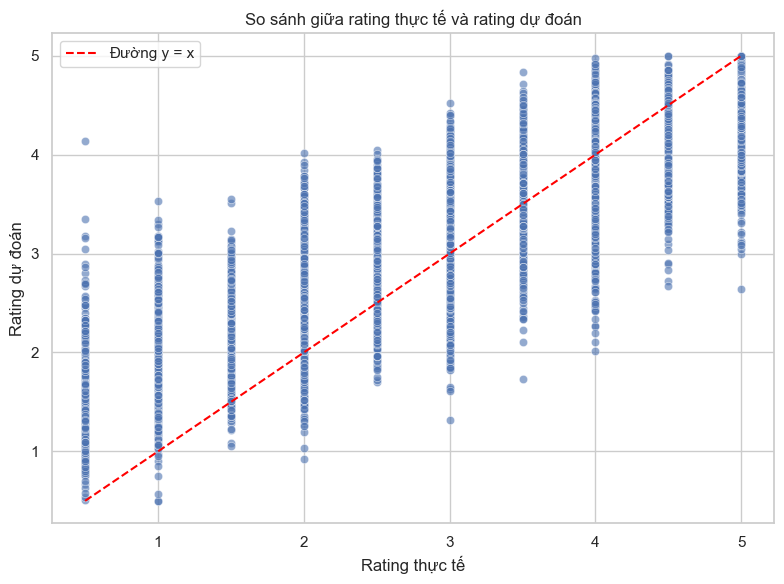

In [ ]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

predictions = loaded_model.test(testset)

true_ratings = [pred.r_ui for pred in predictions]
pred_ratings = [pred.est for pred in predictions]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=true_ratings, y=pred_ratings, alpha=0.6)
plt.plot([0.5, 5], [0.5, 5], '--', color='red', label='Đường y = x')
plt.xlabel("Rating thực tế")
plt.ylabel("Rating dự đoán")
plt.title("So sánh giữa rating thực tế và rating dự đoán")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()